# SDS210-Project: An analysis of the "Züri Wie Neu" data

### Data

In [1]:
import pandas as pd
import geopandas as gpd

#read data (all datasets which are necessary to answer questions 1-4) 
#if necessary create subsets to reduce the size of the data
meldungen_csv = gpd.read_file("data/raw/stzh.zwn_meldungen_p.json") #name a bit misleading, but used in the code too many times to change now
meldungen_csv = meldungen_csv[["objectid", "requested_datetime", "e", "n", "service_code", "geometry"]]

quartiere_json = gpd.read_file("data/raw/stzh.adm_statistische_quartiere_v.json")
quartiere_csv = gpd.read_file("data/raw/stzh.adm_statistische_quartiere_v.csv")

fläche_csv = pd.read_csv("data/raw/bevölkerung_zh2.csv")
fläche_csv = fläche_csv[["RaumKategorie", "RaumSort", "RaumLang", "FlaecheT"]]


### Quick overview on the datasets (can be skipped or commented, but important to see what we are working with)

In [ ]:
#overview of columns of different datasets 
print("Meldungen CSV:", meldungen_csv.columns)
print("Quartiere JSON:", quartiere_json.columns)
print("Quartiere CSV", quartiere_csv.columns)
print("Fläche CSV:", fläche_csv.columns)

Meldungen CSV: Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='str')
Quartiere JSON: Index(['objid', 'objectid', 'geometry'], dtype='str')
Quartiere CSV Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='str')
Fläche CSV: Index(['RaumKategorie', 'RaumSort', 'RaumLang', 'StichtagDatJahr', 'FlaecheT',
       'FlaecheL', 'FlaecheS'],
      dtype='str')


### Question 1a

Which is the category with the highest number of reports?  

In [2]:
#count the number of reports per category (service_code)
anzahl_meldungen = meldungen_csv.groupby("service_code").size().reset_index(name = "anzahl_meldungen")


#sort it and display to answer the question 
display(anzahl_meldungen.sort_values("anzahl_meldungen", ascending = False))

,service_code,anzahl_meldungen
0,Abfall/Sammelstelle,27339
7,Signalisation/Lichtsignal,10975
8,Strasse/Trottoir/Platz,9870
5,Grünflächen/Spielplätze,7238
2,Beleuchtung/Uhren,5407
1,Allgemein,3969
4,Graffiti,3759
9,VBZ/ÖV,1882
3,Brunnen/Hydranten,1289
6,Schädlinge,895


### Question 1b

Which are the top 3 'Quartiere'/'Kreise' with the most reports? 

In [3]:
from shapely.geometry import Point
import geopandas as gpd

#ensure the correct CRS
quartiere_ch = quartiere_json.to_crs(epsg = 2056)


#merge quartiere_json and _csv to combine spatial data and important attributes (+ set active geometry)
quartiere_gdf = quartiere_json.merge(
    quartiere_csv, on = "objid", how = "left").set_geometry("geometry_x").to_crs(epsg = 2056)


#create geometries from meldungen_csv
meldungen_gdf = gpd.GeoDataFrame(
    meldungen_csv,
    geometry=gpd.points_from_xy(meldungen_csv["e"], meldungen_csv["n"]),
    crs=quartiere_ch.crs)
meldungen_ch = meldungen_gdf.to_crs(epsg = 2056)


#spatial join of meldungen und quartiere
meldungen_quartier_join = gpd.sjoin(
    meldungen_ch, #left
    quartiere_gdf, #right
    how = "inner", predicate = "intersects")


#calculate number of reports (meldungen) per 'Quartier' and 'Kreis' 
meldungen_pro_quartier = (meldungen_quartier_join.groupby("qname").size().reset_index(name = "anzahl_meldungen_quartier"))
display(meldungen_pro_quartier.sort_values("anzahl_meldungen_quartier", ascending = False)) #could add .head(3) to only see the top 3 quartiere, but as I want to get to know the data, I leave it away here

meldungen_pro_kreis = (meldungen_quartier_join.groupby("kname").size().reset_index(name = "anzahl_meldungen_kreis"))
display(meldungen_pro_kreis.sort_values("anzahl_meldungen_kreis", ascending = False))

#add the newly calculated values to the join 
meldungen_quartier_join = meldungen_quartier_join.merge(
    meldungen_pro_kreis,
    on = "kname",
    how = "left")


meldungen_quartier_join = meldungen_quartier_join.merge(
    meldungen_pro_quartier,
    on = "qname",
    how = "left")


#again reduce the number of attributes 
meldungen_quartier_join = meldungen_quartier_join[["objectid", "requested_datetime", "e", "n", "service_code", "geometry", "index_right", "qname", "qnr", "kname", "knr", "geometry_y", "anzahl_meldungen_quartier", "anzahl_meldungen_kreis"]]


,qname,anzahl_meldungen_quartier
16,Langstrasse,6185
27,Sihlfeld,5235
3,Altstetten,4094
28,Unterstrass,3594
31,Wipkingen,3304
15,Höngg,3090
21,Oerlikon,2985
10,Hard,2855
33,Wollishofen,2837
5,Enge,2756


,kname,anzahl_meldungen_kreis
6,Kreis 4,10569
5,Kreis 3,9152
2,Kreis 11,8026
1,Kreis 10,6394
4,Kreis 2,6225
11,Kreis 9,6142
0,Kreis 1,5738
9,Kreis 7,5714
8,Kreis 6,5110
7,Kreis 5,3792


### Question 2

Is the density of reports higher around the lake than elsewhere? 
Assumption: "Around the lake" includes 'Kreise' 1,2 and 8

In [4]:
#create subsets to reduce the size of the datasets 
quartiere_subset = quartiere_gdf[["objid", "geometry_x", "kname", "knr"]]

fläche_subset = fläche_csv[fläche_csv["RaumLang"].str.contains("Kreis", na = False)]
fläche_subset = fläche_subset.groupby("RaumLang", as_index = False)["FlaecheT"].mean() #I only ont one value per 'Kreis' and not several ones


#join the fläche_subset with the meldungen_quartier_join
join_fläche_meldungen = fläche_subset.merge(
    meldungen_quartier_join[["kname", "anzahl_meldungen_kreis"]],
    left_on = "RaumLang", 
    right_on = "kname", 
    how = "left")


#calculate the report density per area (here:hectares)
join_fläche_meldungen["meldungsdichte_kreis"] = join_fläche_meldungen["anzahl_meldungen_kreis"]/join_fläche_meldungen["FlaecheT"]


#merge the report density with the meldungen_quartier_join 
quartiere_subset = quartiere_subset.merge(
    join_fläche_meldungen[["meldungsdichte_kreis", "RaumLang"]],
    left_on = "kname", 
    right_on = "RaumLang",
    how = "inner")


#as long as the visualization does not work, let's do it with a table for the moment
quartiere_subset_table = quartiere_subset[["meldungsdichte_kreis", "kname"]].groupby("kname").mean()
display(quartiere_subset_table.sort_values("meldungsdichte_kreis", ascending = False))


,meldungsdichte_kreis
kname,
Kreis 4,36.617890
Kreis 1,31.800874
Kreis 5,18.846367
Kreis 3,10.579483
Kreis 6,10.014641
Kreis 10,7.036699
Kreis 8,6.245434
Kreis 11,5.976068
Kreis 2,5.624173


Visualization to question 2

Text(0.5, 0.98, "Report Density Mapped per 'Kreis'")

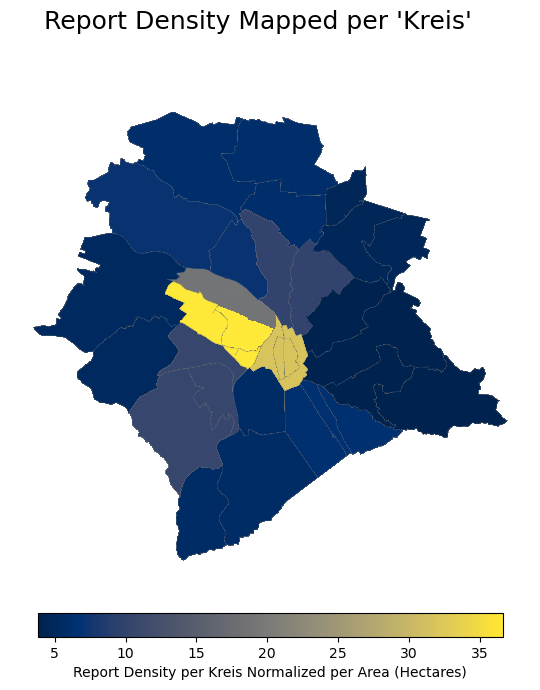

In [6]:
import matplotlib.pyplot as plt

#create the empty subplots 
fig, ax = plt.subplots(figsize=(10, 8)) #set up figure and axes


#create a legend 
legend_options = {
    "label": "Report Density per Kreis Normalized per Area (Hectares)",
    "orientation": "horizontal",
    "shrink": 0.6,
    "pad" : 0.05}


#combine the previous elements to a plot
charte_plot = quartiere_subset.plot(
    ax = ax, 
    column = "meldungsdichte_kreis",
    cmap = "cividis",
    legend = True,
    legend_kwds = legend_options,
    edgecolor = "grey",
    linewidth = 0.1)

ax.set_axis_off()

fig.suptitle("Report Density Mapped per 'Kreis'", fontsize = 18)


### Question 3

How does the report density around the lake differ between august (summer) and january (winter)?

In [ ]:
import geopandas as gpd
import pandas as pd

# parse date in meldungen_quartier_join (preparation to later filter after this)
meldungen_quartier_join["requested_datetime"] = pd.to_datetime(
    meldungen_quartier_join["requested_datetime"], format = "%Y%m%d%H%M%S")


#create a subset which only contains the data about the 'Kreise' around the lake (1,2,8)
kreise_see = meldungen_quartier_join[meldungen_quartier_join["knr"].isin(["1", "2", "8"])]


#create a function to filter the reports per month and year
def filter_by_month(data, year = None, month = None):
    """
    define a function that filters the input data by year and month
    ---
    parameters
    data: pd.DataFrame of "Züri Wie Neu" reports that contains a column name 'requested_datetime' with datetime values (parsed dates follow the format 01-01-2000)
    year: int, optional, for filtering, between 2013 and 2026, if None: no filtering by year applied
    month: int, optional, for filtering, between 1 and 12, if None: no filtering by month applied
    ---
    returns
    pd.DataFrame
    filtered dataframe that only contains the rows that match the specified month and year 3 
    """
    result = data.copy()

    if year is not None:
        result = result[result["requested_datetime"].dt.year == year]

    if month is not None:
        result = result[result["requested_datetime"].dt.month == month] 

    return result

#apply function to filter august and january data
august_daten = filter_by_month(kreise_see, month = 8)
august_daten = august_daten.set_index("requested_datetime")
januar_daten = filter_by_month(kreise_see, month = 1)
januar_daten = januar_daten.set_index("requested_datetime")


#compare the reports per month in a specific year
august_daten_2025 = filter_by_month(kreise_see, year = 2025, month = 8)
januar_daten_2025 = filter_by_month(kreise_see, year = 2025, month = 1)


#count number of reports
print(f"Number of Reports in August Around the Lake (over full period): {len(august_daten)}")
print(f"Number of Reports in January Around the Lake (over full period): {len(januar_daten)}")

print(f"Number of Reports in August Around the Lake 2025: {len(august_daten_2025)}")
print(f"Number of Reports in January Around the Lake 2025: {len(januar_daten_2025)}")


Number of Reports in August Around the Lake (over full period): 1625
Number of Reports in January Around the Lake (over full period): 1057
Number of Reports in August Around the Lake 2025: 246
Number of Reports in January Around the Lake 2025: 184


Visualization to question 3

Text(0.5, 0.98, "Comparison of Report Number in the Lakeside 'Kreise' in January vs August Over the Full Report Period")

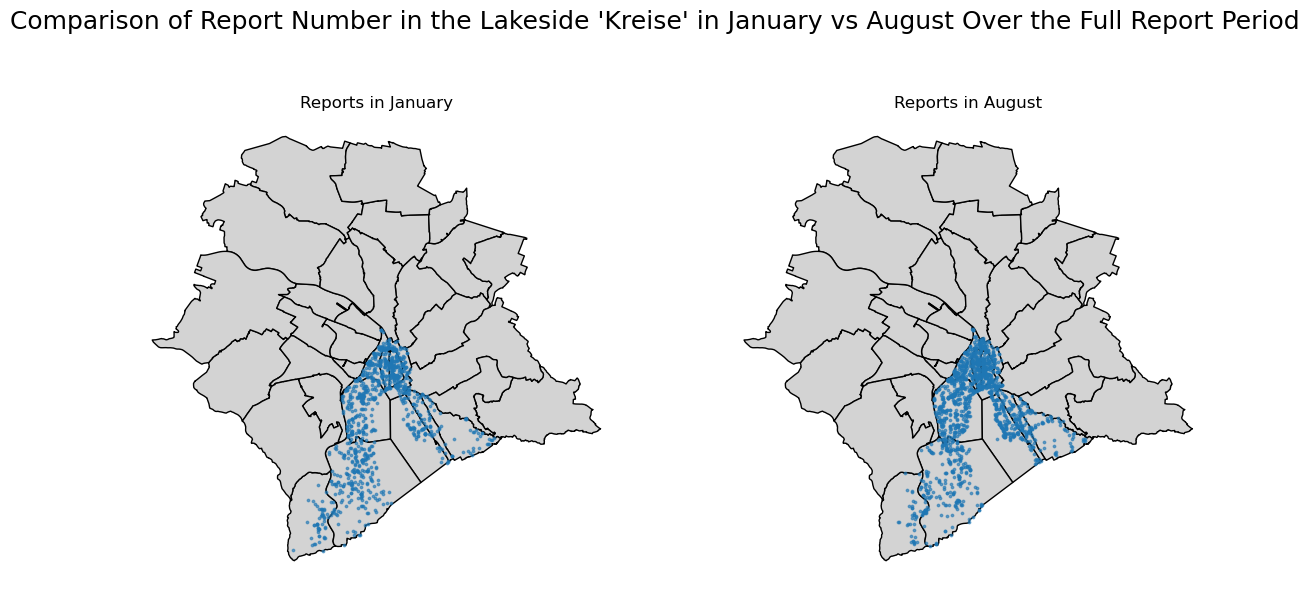

In [ ]:

import matplotlib.pyplot as plt

#create figure with 2 plots next to each other
fig, ax = plt.subplots(1, 2, figsize = (14, 7))

#plot january
quartiere_gdf.plot(
    ax = ax[0],
    color = "lightgrey",
    edgecolor = "black")

januar_daten.plot(
    ax = ax[0], 
    markersize = 3,
    alpha = 0.6)

ax[0].set_title(f"Reports in January")
ax[0].axis("off")

#plot august
quartiere_gdf.plot(
    ax = ax[1],
    color = "lightgrey",
    edgecolor = "black")

august_daten.plot(
    ax = ax[1], 
    markersize = 3,
    alpha = 0.6)

ax[1].set_title("Reports in August")
ax[1].axis("off")  

fig.suptitle("Comparison of Report Number in the Lakeside 'Zürcher Kreise' in January vs August Over the Full Report Period", fontsize = 18)

### Question 4

Which trend does the august (summer) and january (winter) data around the lake show within the reporting period?

The  Number of Monthly Reports in August Follows the Trend: -34.3 per year.
The  Number of Monthly Reports in January Follows the Trend: -17.2 per year.


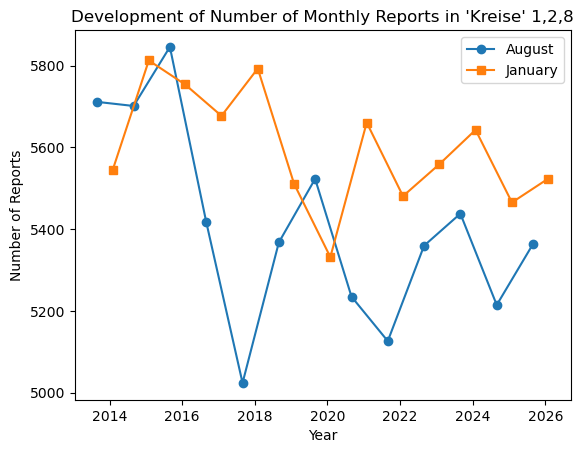

In [12]:
import numpy as np
import matplotlib.pyplot as plt

#resample monthly mean temperatures (means are required for the temporal analysis)
august_mean = august_daten["anzahl_meldungen_kreis"].resample("ME").mean().dropna()
januar_mean = januar_daten["anzahl_meldungen_kreis"].resample("ME").mean().dropna()


#calculate the trend
august_passed = np.arange(len(august_mean))
slope, intercept = np.polyfit(august_passed, august_mean, 1)
januar_passed = np.arange(len(januar_mean))
slope1, intercept1 = np.polyfit(januar_passed, januar_mean, 1)

print(f"The  Number of Monthly Reports in August Follows the Trend: {slope:.1f} per year.")
print(f"The  Number of Monthly Reports in January Follows the Trend: {slope1:.1f} per year.")


#plot the august_mean and januar_mean to observe the changes within the reported period
plt.plot(august_mean, label = "August", marker = "o")
plt.plot(januar_mean, label = "January", marker = "s")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.title("Development of Number of Monthly Reports in 'Kreise' 1,2,8")
plt.show()


### Results

Question 1a: 
The category with the highest number of reports is “Abfall/Sammelstelle”, counting 27’339 reports within the years 2013-2026. 

Question 1b: 
Most reports lie within the Zürcher ‘Kreise’ 4, 3 and 11. Breaking this down to a smaller spatial scale reveals that the most reports are registered within the ‘Quartiere’ Langstrasse (situated in ‘Kreis’ 4), Sihlfeld (lies in ‘Kreis 3’) and Altstetten (within ‘Kreis’ 9).

Question 2: 
The second question can be answered with a no, what means that reports do not cluster around the lake but follow other criteria, for example how central the location is within the city of Zurich. The table depicts this more clearly than the map. The map has another drawback: the lake is also colored in the same colors as the 'Kreise' what is cartogrpahically undesired. However, it is included into the polygons from quartiere_gdf and no dataset was found to extract the lake area, therefore it is what it is. 

Question 3: 
The number of reports around the lake in august is higher than in january, revealing a seasonality (overall: 1’625 reports in august and 1’057 in january; specifically for 2025: 246 reports in august and 184 in january). This confirms the expectation that in summer, when more people spend their time outdoors, the number of reports increases.

Question 4:
The development of the mean monthly number of reports shows an overall decreasing trend (-34 reports per year in august and -17 reports per year in january). However, the trend is not linear. The january reports peak in 2015, 2018, 2021 and 2024 which decrease in size. The number of reports in august show a similar development but more strongly pronounced. The extreme peaks could result from special events, which (in this region) rather take place in summer than in winter.